# Construct a network from one recorded fish configuration

Load one frame from the field-of-view file, calculate pairwise distances and angular-area ranks, and use them to construct a directed response-probability network. Fish and frame indices start at zero. The network uses Sosna et al.'s coefficients with an explicitly assumed distance calibration, then is saved as a separate exploratory artifact. The current [simulation.ipynb](simulation.ipynb) uses a connected random network.


In [1]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
from geometry import pairwise_distances, rank_angular_areas
from network import response_network


## Select the recording and frame

The file is opened read-only. This notebook uses the `pymc_env` kernel, which has `h5py` installed.


In [2]:
data_path = Path(
    "/Users/vivekhsridhar/Library/Mobile Documents/com~apple~CloudDocs/Documents/"
    "Manuscripts/04_leadership/Data/MGrobisData/30-fish/0084/0084_000_fov.h5"
)
frame_index = 0


In [3]:
with h5py.File(data_path, "r") as data:
    n_fish = int(data.attrs["ntracks"])
    n_frames = int(data.attrs["nframes"])

print(f"{n_fish} fish, {n_frames} frames; selected frame {frame_index}")


30 fish, 3596 frames; selected frame 0


## Load positions and headings

These fields are stored as `[fish, frame]`. Each slice below keeps every fish at the selected frame. Coordinate units are not specified in the file metadata, so the plots retain raw units.


In [4]:
with h5py.File(data_path, "r") as data:
    x = data["fields/x"][:, frame_index]
    y = data["fields/y"][:, frame_index]
    heading_x = data["fields/heading_x"][:, frame_index]
    heading_y = data["fields/heading_y"][:, frame_index]
    detected = data["fields/detected"][:, frame_index].astype(bool)


In [5]:
fish_ids = np.arange(n_fish)
print(f"Detected fish: {detected.sum()} / {n_fish}")
print(f"Positions and headings finite: {np.isfinite([x, y, heading_x, heading_y]).all()}")


Detected fish: 30 / 30
Positions and headings finite: True


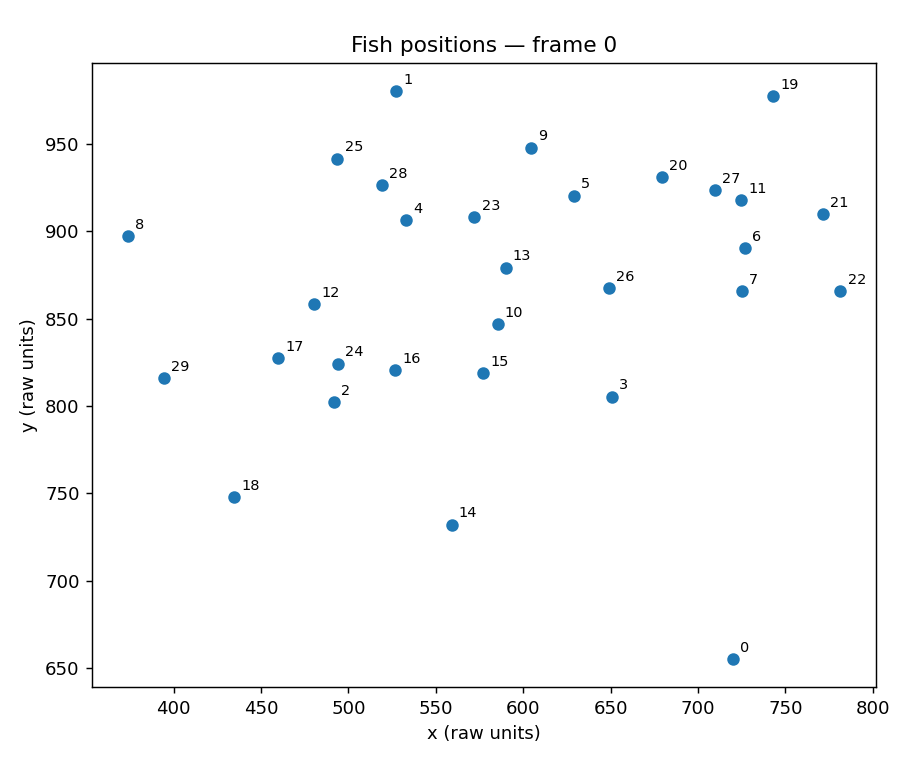

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y, s=35)
for fish_id in fish_ids:
    ax.annotate(str(fish_id), (x[fish_id], y[fish_id]),
                xytext=(4, 4), textcoords="offset points", fontsize=8)
ax.set(xlabel="x (raw units)", ylabel="y (raw units)",
       title=f"Fish positions — frame {frame_index}")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()


## Load pairwise angular areas

These fields are stored as `[focal fish, frame, other fish]`. Selecting a frame gives a square matrix. The nearby [preprocessing notebook](../../../../Manuscripts/04_leadership/Code/01F_preprocess_input_fish.ipynb) uses this ordering and adds the left- and right-eye measurements; we retain both arrays and their sum here.

Rows represent focal fish and columns represent other fish. The focal fish is interpreted as the viewer. Angular-area units still need confirmation. These measurements are not response probabilities, and they need not be symmetric.


In [7]:
with h5py.File(data_path, "r") as data:
    angular_area_left = data["fields/ang_area_left_eye"][:, frame_index, :]
    angular_area_right = data["fields/ang_area_right_eye"][:, frame_index, :]

angular_area = angular_area_left + angular_area_right


In [8]:
self_pairs = np.eye(n_fish, dtype=bool)
print(f"Angular-area matrix shape: {angular_area.shape}")
print(f"Positive off-diagonal entries: {np.count_nonzero((angular_area > 0) & ~self_pairs)}")
print("Fish with nonzero self-area:", fish_ids[np.diag(angular_area) != 0])


Angular-area matrix shape: (30, 30)
Positive off-diagonal entries: 511
Fish with nonzero self-area: [16]


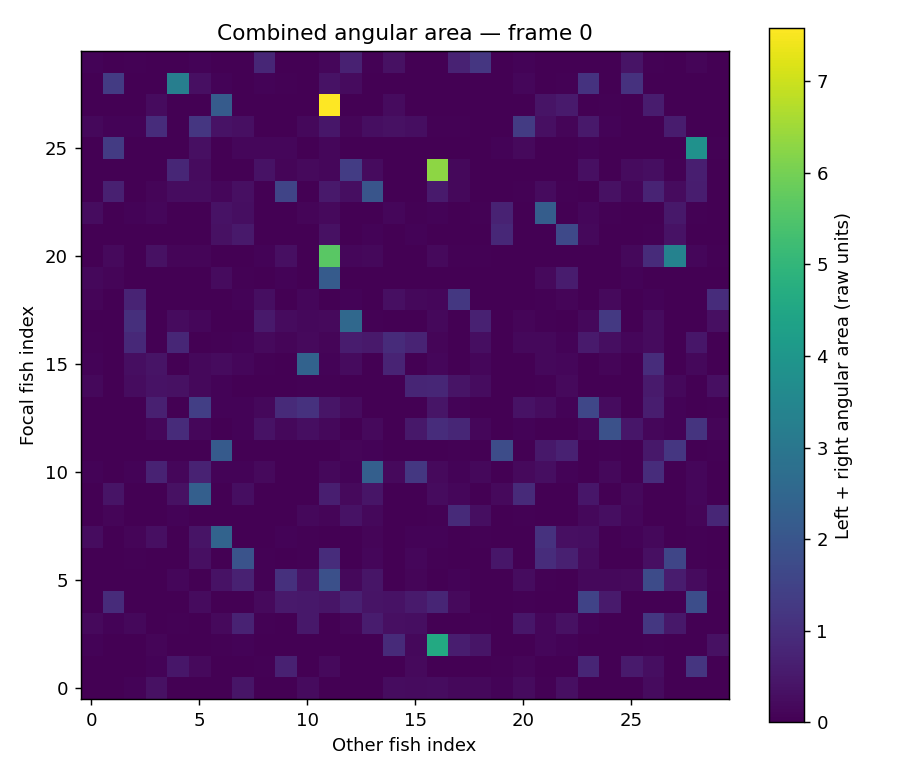

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
area_plot = ax.imshow(angular_area, origin="lower", cmap="viridis")
ax.set(xlabel="Other fish index", ylabel="Focal fish index",
       title=f"Combined angular area — frame {frame_index}")
fig.colorbar(area_plot, ax=ax, label="Left + right angular area (raw units)")
fig.tight_layout()
plt.show()


The heatmap preserves the raw diagonal, including any nonzero self-area. Self-pairs are excluded before ranking neighbours or counting connections in a future network.


## Calculate pairwise distances

`distance[i, j]` is the Euclidean distance between the recorded positions of fish `i` and `j`. The function in [geometry.py](geometry.py) calculates the x and y differences for every pair, then combines them using the Pythagorean theorem. This matrix is symmetric, with zero distance on the diagonal.


In [10]:
distance = pairwise_distances(x, y)
print(f"Distance matrix shape: {distance.shape}")
print(f"Distances between different fish: {distance[~self_pairs].min():.2f} to {distance[~self_pairs].max():.2f} raw units")


Distance matrix shape: (30, 30)
Distances between different fish: 16.01 to 422.33 raw units


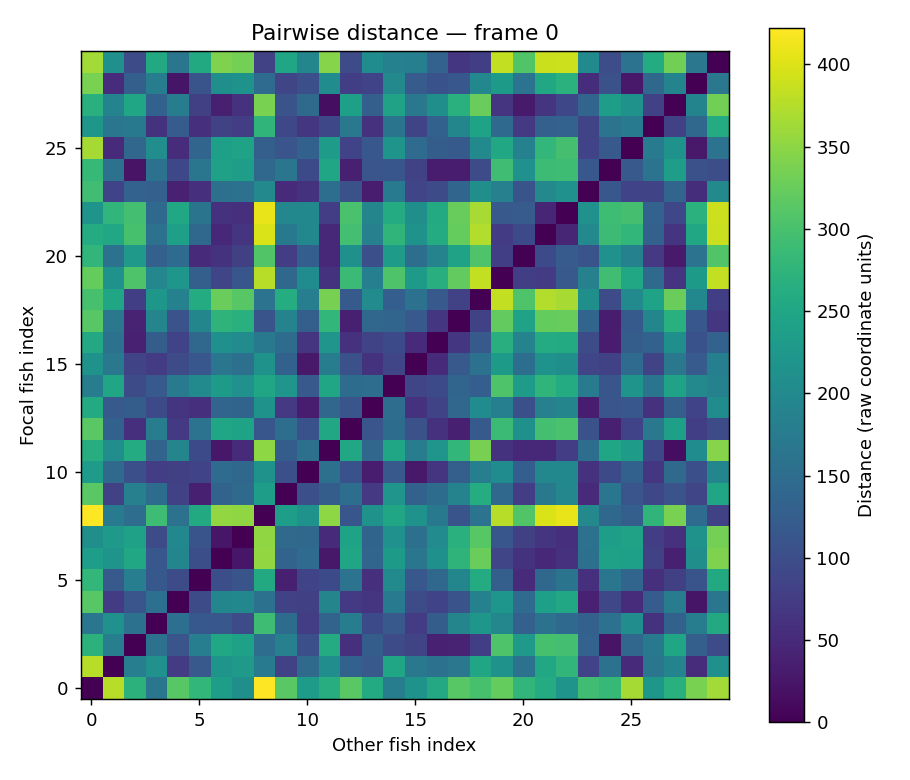

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
distance_plot = ax.imshow(distance, origin="lower", cmap="viridis")
ax.set(xlabel="Other fish index", ylabel="Focal fish index",
       title=f"Pairwise distance — frame {frame_index}")
fig.colorbar(distance_plot, ax=ax, label="Distance (raw coordinate units)")
fig.tight_layout()
plt.show()


Sosna et al. plot distances in centimetres (main paper, Fig. 3). Their [dataset README](https://zenodo.org/records/6270624/files/README.md) specifies a base-10 logarithm for the distance predictor. The coordinate-to-centimetre conversion for this recording is not established here, so `distance` remains in raw units.

If `distance_cm = cm_per_unit * distance`, then `log10(distance_cm) = log10(distance) + log10(cm_per_unit)`. A unit conversion therefore shifts the distance term in the fitted logistic model. We need the conversion, or an equivalent adjustment to the intercept, before applying coefficients fitted in centimetres. Angular-area ranks do not change under a uniform positive rescaling of angular area.


## Rank angular areas for each viewer

The [dataset README](https://zenodo.org/records/6270624/files/README.md) defines rank 1 as the fish occupying the largest angular area in the focal fish's view. Following SI section 6.1, equation S3, `angular_area_rank[i, j]` ranks fish `j` in the view of fish `i`. Ranks are calculated separately within each row. Fish indices remain zero-based; the predictor's ranks start at one.

Here, positive combined angular area identifies a visible pair; no additional visibility cutoff is imposed. Self-pairs are excluded before ranking. Equal areas receive their average rank: a tie occupying positions 2 and 3 gives both fish rank 2.5. This tie convention is our explicit choice because the available paper documentation does not specify it. Self-pairs and zero-area pairs receive `NaN`, meaning no rank. The raw angular-area matrix remains unchanged.


In [12]:
angular_area_rank = rank_angular_areas(angular_area)
visible = np.isfinite(angular_area_rank)
print(f"Ranked pairs: {visible.sum()}")
print(f"Visible neighbours per fish: {visible.sum(axis=1).min()} to {visible.sum(axis=1).max()}")


Ranked pairs: 511
Visible neighbours per fish: 8 to 23


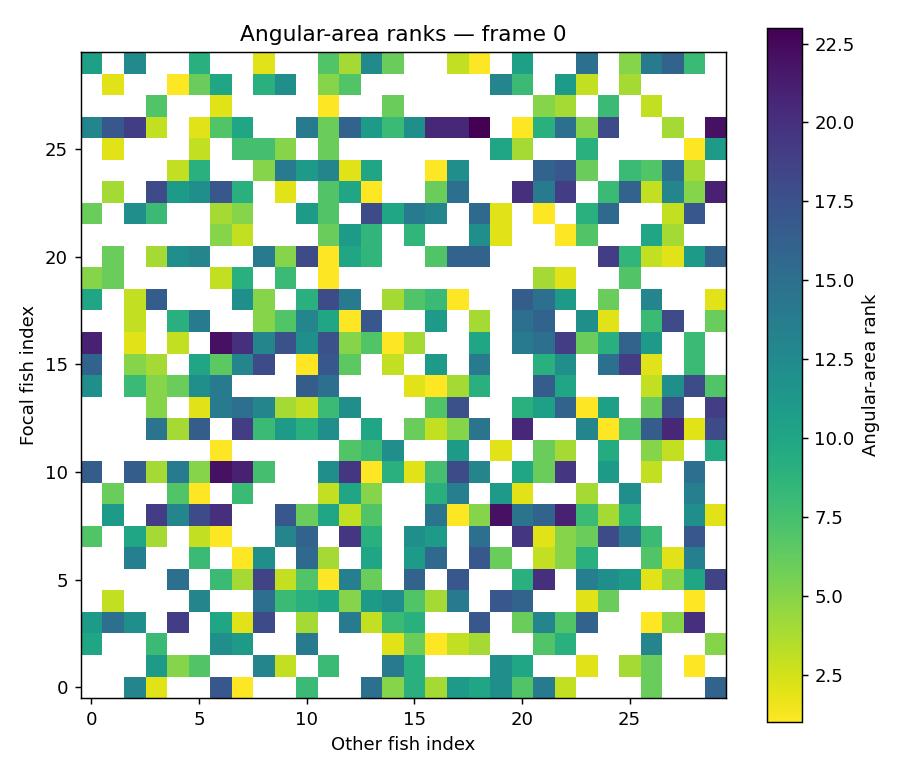

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
rank_plot = ax.imshow(angular_area_rank, origin="lower", cmap="viridis_r")
ax.set(xlabel="Other fish index", ylabel="Focal fish index",
       title=f"Angular-area ranks — frame {frame_index}")
fig.colorbar(rank_plot, ax=ax, label="Angular-area rank")
fig.tight_layout()
plt.show()


Blank cells have no rank. The table below follows one focal fish and lists its visible neighbours in rank order, alongside their distances and raw combined angular areas.


In [14]:
focal_fish = 0
neighbours = np.flatnonzero(visible[focal_fish])
rank_order = np.argsort(angular_area_rank[focal_fish, neighbours])
neighbours = neighbours[rank_order]


In [15]:
print(f"Focal fish {focal_fish}")
print("Fish  Distance (raw)  Angular area (raw)  Rank")
for neighbour in neighbours:
    print(f"{neighbour:4d}  {distance[focal_fish, neighbour]:14.2f}  "
          f"{angular_area[focal_fish, neighbour]:18.4f}  "
          f"{angular_area_rank[focal_fish, neighbour]:4.1f}")


Focal fish 0
Fish  Distance (raw)  Angular area (raw)  Rank
   7          210.26              0.4273   1.0
   3          165.42              0.3393   2.0
  22          219.14              0.3173   3.0
  16          254.52              0.2576   4.0
  14          178.52              0.2450   5.0
  26          223.74              0.2293   6.0
  20          278.63              0.2231   7.0
  10          234.04              0.2136   8.0
  15          217.50              0.2073   9.0
  18          300.21              0.1634  10.0
  17          312.22              0.1571  11.0
  19          322.63              0.0848  12.0
   2          271.39              0.0660  13.0
  21          259.50              0.0565  14.0
  13          258.94              0.0157  15.0
  29          363.26              0.0126  16.0
   6          235.05              0.0094  17.0


`distance` and `angular_area_rank` are aligned: row `i` is the focal fish and column `j` is the potential sender. Distances are symmetric, whereas ranks generally differ by direction.


## Apply an approximate distance scale

Sosna et al. report an average fish length of 5.5 cm (SI section 1.1). We explicitly assume that the median `body_length` in this frame corresponds to that length. This borrows a typical size from their experiment; it does not establish the physical calibration of this recording or validate the tracking length estimates. Changing `assumed_body_length_cm` changes the response weights and can change the cascades.


In [16]:
assumed_body_length_cm = 5.5
with h5py.File(data_path, "r") as data:
    body_length = data["fields/body_length"][:, frame_index]


In [17]:
cm_per_unit = assumed_body_length_cm / np.median(body_length)
distance_cm = distance * cm_per_unit
print(f"Assumed scale: {cm_per_unit:.5f} cm per raw unit")


Assumed scale: 0.07292 cm per raw unit


## Calculate response probabilities

For visible pairs, the weight is `logistic(intercept + distance_coefficient * log10(distance_cm) + rank_coefficient * angular_area_rank)`. These coefficients are the pooled first-exposure values explicitly given in [Sosna's supplement](<../../../../Literature/Collective Behaviour/Sosna et al. 2019 PNAS - SI.pdf>), section 6.1, page 8. They combine the baseline and post-Schreckstoff data.

`adjacency[i, j]` describes the influence of fish `j` on fish `i`. Self-pairs and pairs without positive angular area have zero weight. The logistic calculation is applied only to ranked pairs, so it does not take the logarithm of self-distance. The rows are not normalized: the simulation already divides received doses by the number of incoming neighbours.


In [18]:
intercept = 0.06449
distance_coefficient = -3.20552
rank_coefficient = -0.08016


In [19]:
adjacency = response_network(
    distance_cm, angular_area_rank, intercept, distance_coefficient, rank_coefficient,
)
print(f"Directed links: {np.count_nonzero(adjacency)}")
print(f"Positive weights: {adjacency[visible].min():.4f} to {adjacency[visible].max():.4f}")


Directed links: 511
Positive weights: 0.0018 to 0.4424


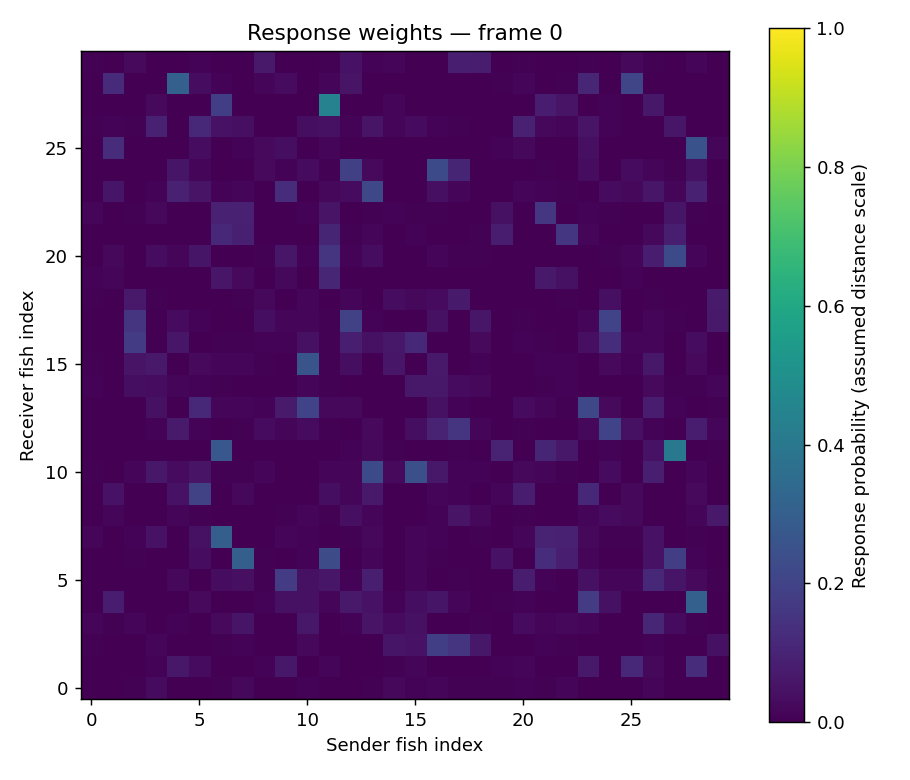

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
weight_plot = ax.imshow(adjacency, origin="lower", cmap="viridis", vmin=0, vmax=1)
ax.set(xlabel="Sender fish index", ylabel="Receiver fish index",
       title=f"Response weights — frame {frame_index}")
fig.colorbar(weight_plot, ax=ax, label="Response probability (assumed distance scale)")
fig.tight_layout()
plt.show()


## Save the exploratory network

The file stores the weights, fish positions, selected frame, assumed scale, assumed body length, coefficients, and source path. Run this notebook from `P2_PulseCoupledEscape/`. Rerunning this cell replaces the saved network with the current selection. The current simulation generates a connected random network and does not load this file.


In [21]:
network_path = Path("visual_network.npz")
np.savez(
    network_path, adjacency=adjacency, x=x, y=y, frame_index=frame_index,
    cm_per_unit=cm_per_unit, assumed_body_length_cm=assumed_body_length_cm,
    coefficients=np.array([intercept, distance_coefficient, rank_coefficient]),
    source_path=str(data_path),
)
print(f"Saved {network_path}: {n_fish} fish")


Saved visual_network.npz: 30 fish
